In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


c:\CondaEnvs\opus-ai\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


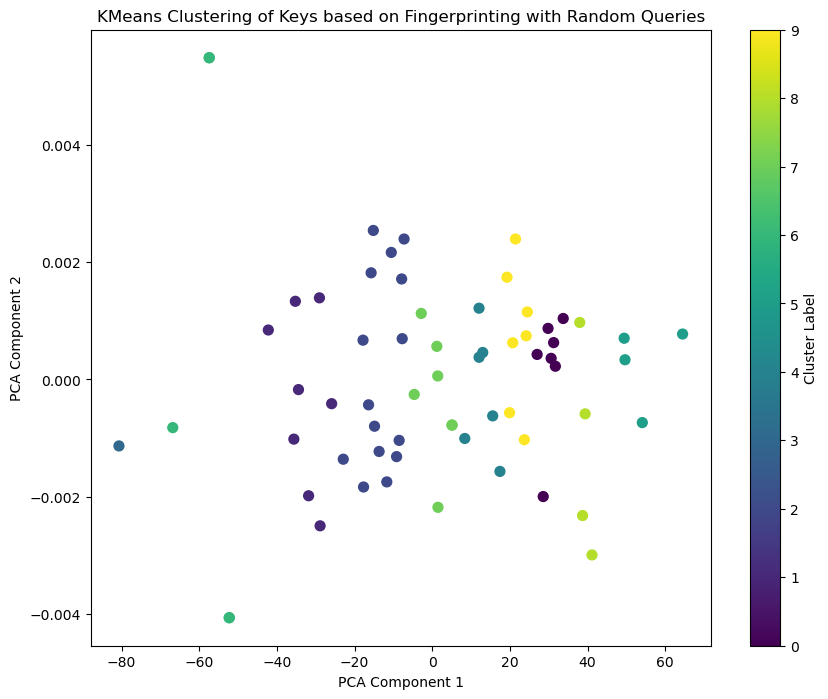

In [ ]:
# first we generate 1000 random prefill tokens with hidden dimension of 768
num_tokens = 1000

prefill = torch.rand(num_tokens, 768)

w_k = torch.rand(768, 768)
w_v = torch.rand(768, 768)
w_q = torch.rand(768, 768)

k = torch.matmul(prefill, w_k)
v = torch.matmul(prefill, w_v)
q = torch.matmul(prefill, w_q)

# now we want to cluster the keys based on fingerprinting them to 64 randomly chosen queries. so we first select 64 random queries from the prefill tokens, compute the scores of all keys with those queries and use those scores to cluster

q_fingerprint = q[torch.randint(0, num_tokens, (64,))]
scores = torch.matmul(q_fingerprint, k.T)

# now we can use sklearn's KMeans to cluster the keys based on the scores
scaler = StandardScaler()
scores_scaled = scaler.fit_transform(scores.cpu().numpy())

kmeans = KMeans(n_clusters=64, random_state=0, init='k-means++').fit(scores_scaled)
cluster_labels = kmeans.labels_

# now we can visualize the clusters using PCA to reduce the dimensionality of the scores to 2D
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
scores_pca = pca.fit_transform(scores_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(scores_pca[:, 0], scores_pca[:, 1], c=cluster_labels, cmap='viridis', s=50)
plt.title('KMeans Clustering of Keys based on Fingerprinting with Random Queries')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

# now that we hvae clustered the keys, we can compute the average key for each cluster and the number of keys per cluster and store that in a new tensor
average_keys = torch.zeros(64, 768)
cluster_counts = torch.zeros(64)
for i in range(64):
    cluster_keys = k[cluster_labels == i]
    average_keys[i] = torch.mean(cluster_keys, dim=0)
    cluster_counts[i] = cluster_keys.shape[0]

# now we sample from each cluster based on its score relate to the total score of all cluster
    
